# 📦 M1+M2: Data Sourcing & Annotation (drone vs bird)
**Computer Vision | Group Project | IE University MBDS-SEP25**

**Scope:** Dataset acquisition, annotation verification, and train/val/test split

This notebook downloads the Roboflow Universe "drone-vs-bird" dataset (v3, YOLOv11 format), verifies annotation quality through visual inspection and class-balance analysis, checks for train/val/test leakage, and reorganises the export into the project's folder layout on Google Drive.

**Why Roboflow and not a custom collection?**
The dataset ships with YOLO-format annotations for two classes (`bird` and `drone`) covering a range of backgrounds, distances, and lighting conditions. Collecting and annotating comparable imagery from scratch would take weeks; Roboflow provides a vetted, ready-to-use baseline that meets the assignment requirement of a prepared and annotated image dataset.

**Why verify annotations manually?**
Pretrained annotation is not perfect. Visual inspection catches systematic errors (swapped class labels, missing objects, wrong bounding-box placement) before they propagate to training. The class-balance check motivates the `copy_paste` augmentation used in M3, and the leakage test confirms the split is clean.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



📁 Changed working directory to /content/drive/MyDrive/!CVIS

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to drone-vs-bird-object-detection-3 in yolov11:: 100%|██████████| 5578/5578 [01:23<00:00, 66.85it/s]



✅ Dataset downloaded to: /content/drive/MyDrive/!CVIS/drone-vs-bird-object-detection-3

Classes (id -> name): {0: 'bird', 1: 'drone'}

Splits found: ['train', 'valid', 'test']

STEP 3 — VISUAL VERIFY


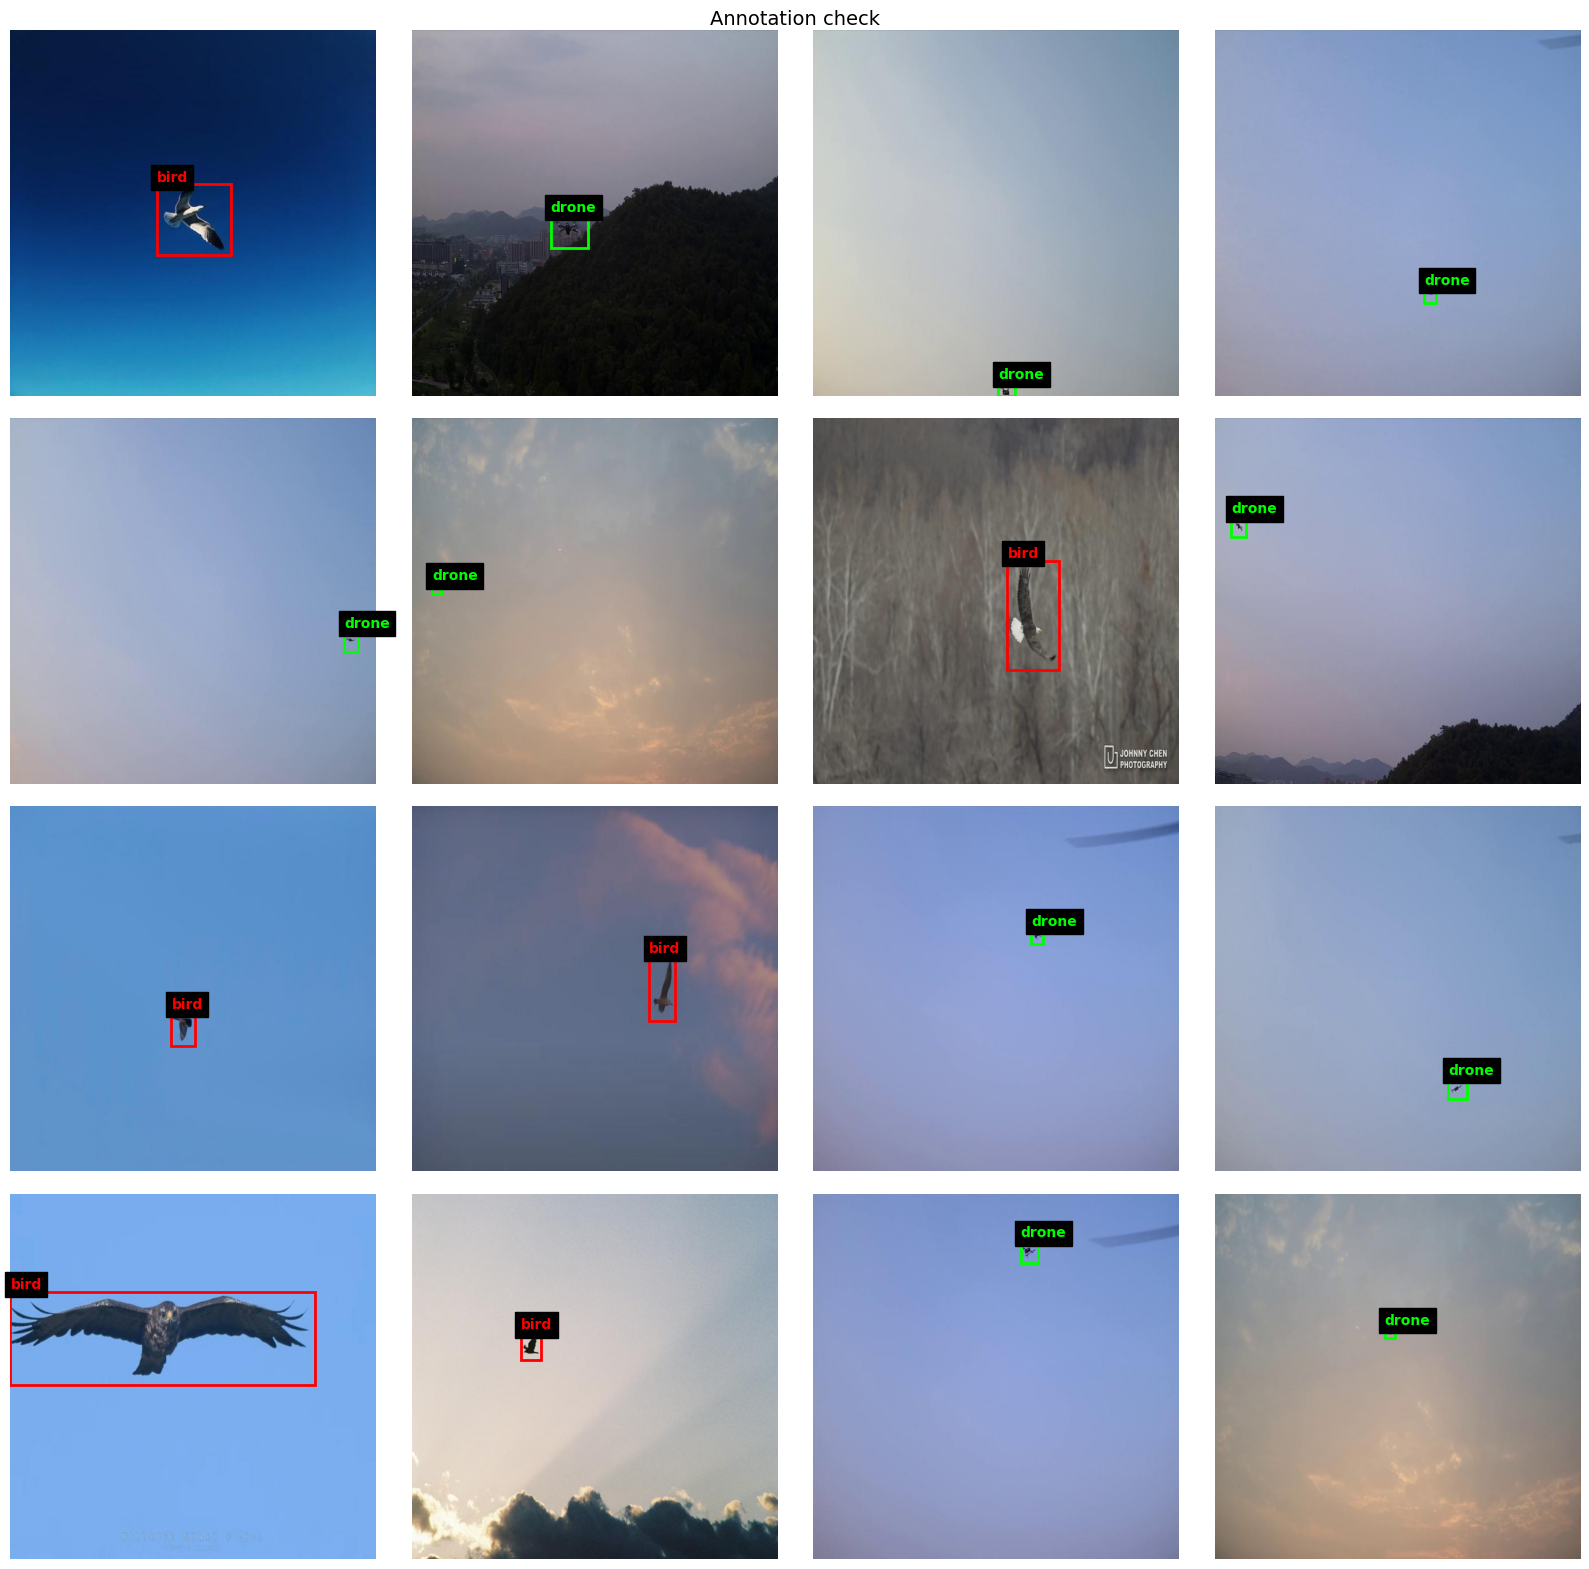

👉👉👉 SANITY CHECK | Drone label on a drone? Bird on a bird? 
STEP 4 & 5 — CLASS BALANCE  +  SPLIT SANITY

Images per split:
  train :  1950 images  (70%)  | 0 with NO label file
  valid :   555 images  (20%)  | 0 with NO label file
  test  :   278 images  (10%)  | 0 with NO label file
  TOTAL : 2783 images

Box (instance) counts per class:
  split  |     bird |    drone
  train  |      853 |     1405
  valid  |      246 |      415
  test   |      103 |      199
  TOTAL  |     1202 |     2019

Class balance (share of all boxes):
  bird    :   1202 boxes  (37.3%)
  drone   :   2019 boxes  (62.7%)
  -> imbalance ratio (most:least) = 1.7 : 1
  ⚠️  'bird' is underrepresented — this is what your copy_paste augmentation (already in the config) is for.

Leakage check (same image in 2+ splits = BAD):
  ✅ No leakage — every image lives in exactly one split.

STEP 6 — CLASS DISTRIBUTION PLOT


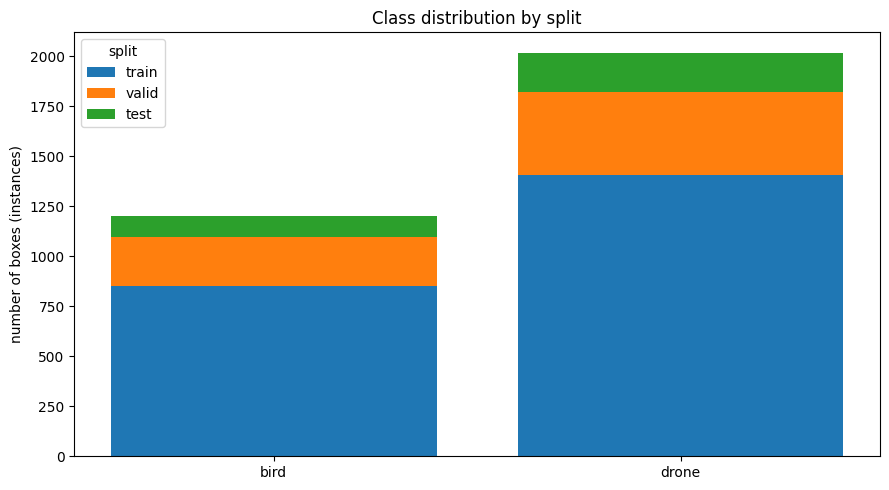


✅ Done. 'class_distribution.png' saved — drop it in results/ and reuse it on a slide.


In [19]:
# ---- 0. Install deps ----
!pip install -q roboflow ultralytics matplotlib

import os, glob, random, collections
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import yaml

# ---- Set working directory to Drive ----
TARGET_DIR = "/content/drive/MyDrive/!CVIS"
os.makedirs(TARGET_DIR, exist_ok=True)
os.chdir(TARGET_DIR)
print(f"\n📁 Changed working directory to {TARGET_DIR}\n")

# ---- 1. Downloads the dataset from Roboflow --------------------
from roboflow import Roboflow

ROBOFLOW_API_KEY = ROBOFLOW_API_KEY

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("avionicsdata").project("drone-vs-bird-object-detection")
dataset = project.version(3).download("yolov11")

DATA_DIR = dataset.location
print(f"\n✅ Dataset downloaded to: {DATA_DIR}\n")

# ---- 2. Read data.yaml to get class names in the right order --
with open(os.path.join(DATA_DIR, "data.yaml")) as f:
    data_yaml = yaml.safe_load(f)

CLASS_NAMES = data_yaml["names"]          # e.g. ['drone', 'bird']
print(f"Classes (id -> name): {dict(enumerate(CLASS_NAMES))}\n")

# Roboflow usually exports: train/ valid/ test/  (note: 'valid' not 'val')
SPLITS = [s for s in ["train", "valid", "test"]
          if os.path.isdir(os.path.join(DATA_DIR, s, "images"))]
print(f"Splits found: {SPLITS}\n")


def list_images(split):
    p = os.path.join(DATA_DIR, split, "images")
    return sorted(glob.glob(os.path.join(p, "*.jpg")) +
                  glob.glob(os.path.join(p, "*.png")))

def label_path_for(img_path):
    # images/foo.jpg  ->  labels/foo.txt
    base = os.path.splitext(os.path.basename(img_path))[0]
    split_dir = os.path.dirname(os.path.dirname(img_path))
    return os.path.join(split_dir, "labels", base + ".txt")

def read_boxes(label_file):
    """Returns list of (class_id, xc, yc, w, h) — all normalized 0..1."""
    if not os.path.exists(label_file):
        return []
    rows = []
    with open(label_file) as f:
        for line in f:
            parts = line.split()
            if len(parts) == 5:
                cid = int(parts[0])
                xc, yc, w, h = map(float, parts[1:])
                rows.append((cid, xc, yc, w, h))
    return rows


# ---- 3. VERIFY: draw boxes on 16 random training images -------
print("="*60)
print("STEP 3 — VISUAL VERIFY")
print("="*60)

train_imgs = list_images("train")
sample = random.sample(train_imgs, min(16, len(train_imgs)))

colors = ["red", "lime", "cyan", "yellow", "magenta"]  # per class id
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, img_path in zip(axes.flat, sample):
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img)
    for cid, xc, yc, w, h in read_boxes(label_path_for(img_path)):
        # YOLO normalized center+size -> pixel top-left corner
        x = (xc - w/2) * W
        y = (yc - h/2) * H
        rect = patches.Rectangle((x, y), w*W, h*H, linewidth=2,
                                 edgecolor=colors[cid % len(colors)],
                                 facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y-5, 0), CLASS_NAMES[cid],
                color=colors[cid % len(colors)], fontsize=10,
                weight="bold", backgroundcolor="black")
    ax.axis("off")
for ax in axes.flat[len(sample):]:
    ax.axis("off")
plt.suptitle("Annotation check",
             fontsize=14)
plt.tight_layout()
plt.show()
print("👉👉👉 SANITY CHECK | Drone label on a drone? Bird on a bird? ")


# ---- 4 & 5. CLASS BALANCE + SPLIT CHECK -----------------------
print("="*60)
print("STEP 4 & 5 — CLASS BALANCE  +  SPLIT SANITY")
print("="*60)

# instances[split][class_id] = box count
instances = {s: collections.Counter() for s in SPLITS}
img_counts = {}
images_with_no_label = {s: 0 for s in SPLITS}
filenames_per_split = {}

for s in SPLITS:
    imgs = list_images(s)
    img_counts[s] = len(imgs)
    filenames_per_split[s] = set(os.path.basename(p) for p in imgs)
    for img_path in imgs:
        boxes = read_boxes(label_path_for(img_path))
        if not boxes:
            images_with_no_label[s] += 1
        for cid, *_ in boxes:
            instances[s][cid] += 1

# --- print image counts + split ratio ---
total_imgs = sum(img_counts.values())
print("\nImages per split:")
for s in SPLITS:
    pct = 100 * img_counts[s] / total_imgs if total_imgs else 0
    print(f"  {s:6s}: {img_counts[s]:5d} images  ({pct:.0f}%)  "
          f"| {images_with_no_label[s]} with NO label file")
print(f"  TOTAL : {total_imgs} images")

# --- print box counts per class ---
print("\nBox (instance) counts per class:")
print(f"  {'split':6s} | " + " | ".join(f"{n:>8s}" for n in CLASS_NAMES))
grand = collections.Counter()
for s in SPLITS:
    row = " | ".join(f"{instances[s][i]:8d}" for i in range(len(CLASS_NAMES)))
    print(f"  {s:6s} | {row}")
    grand.update(instances[s])
total_boxes = sum(grand.values())
print(f"  {'TOTAL':6s} | " +
      " | ".join(f"{grand[i]:8d}" for i in range(len(CLASS_NAMES))))

# --- the imbalance ratio (this justifies your augmentation bonus) ---
print("\nClass balance (share of all boxes):")
for i, name in enumerate(CLASS_NAMES):
    share = 100 * grand[i] / total_boxes if total_boxes else 0
    print(f"  {name:8s}: {grand[i]:6d} boxes  ({share:.1f}%)")
if total_boxes:
    counts = [grand[i] for i in range(len(CLASS_NAMES))]
    ratio = max(counts) / max(min(counts), 1)
    print(f"  -> imbalance ratio (most:least) = {ratio:.1f} : 1")
    if ratio >= 1.5:
        rare = CLASS_NAMES[counts.index(min(counts))]
        print(f"  ⚠️  '{rare}' is underrepresented — this is what your "
              f"copy_paste augmentation (already in the config) is for.")

# --- LEAKAGE check: same filename in two splits = cheating ---
print("\nLeakage check (same image in 2+ splits = BAD):")
leak_found = False
for i, a in enumerate(SPLITS):
    for b in SPLITS[i+1:]:
        overlap = filenames_per_split[a] & filenames_per_split[b]
        if overlap:
            leak_found = True
            print(f"  ❌ {len(overlap)} images shared between "
                  f"{a} and {b} (e.g. {list(overlap)[:3]})")
if not leak_found:
    print("  ✅ No leakage — every image lives in exactly one split.")


# ---- 6. DISTRIBUTION PLOT (your deliverable) ------------------
print("\n" + "="*60)
print("STEP 6 — CLASS DISTRIBUTION PLOT")
print("="*60)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(CLASS_NAMES))
bottom = [0] * len(CLASS_NAMES)
for s in SPLITS:
    vals = [instances[s][i] for i in range(len(CLASS_NAMES))]
    ax.bar(x, vals, bottom=bottom, label=s)
    bottom = [bottom[i] + vals[i] for i in range(len(CLASS_NAMES))]
ax.set_xticks(list(x))
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("number of boxes (instances)")
ax.set_title("Class distribution by split")
ax.legend(title="split")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)   # saved for your slides
plt.show()
print("\n✅ Done. 'class_distribution.png' saved — drop it in results/ "
      "and reuse it on a slide.")

In [21]:
# =============================================================
# Reorganize Roboflow export -> repo layout (data/processed/...)
# =============================================================
import os, shutil, yaml

# Where the cleaned dataset should end up.
# If you've mounted Drive, point this into your Drive folder, e.g.:
TARGET = "/content/drive/MyDrive/!CVIS/data/processed"

# Roboflow exports 'valid'; the repo config expects 'val'.
SPLIT_RENAME = {"train": "train", "valid": "val", "test": "test"}

os.makedirs(TARGET, exist_ok=True)
for src_split, dst_split in SPLIT_RENAME.items():
    src = os.path.join(DATA_DIR, src_split)
    if not os.path.isdir(src):
        print(f"  skip: {src_split} not found")
        continue
    for sub in ["images", "labels"]:
        s = os.path.join(src, sub)
        d = os.path.join(TARGET, dst_split, sub)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
            print(f"  {src_split}/{sub:6s} -> {dst_split}/{sub}  "
                  f"({len(os.listdir(d))} files)")

# Write a corrected data.yaml pointing at the new layout
data_yaml_out = {
    "path": TARGET,
    "train": "train/images",
    "val":   "val/images",
    "test":  "test/images",
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES,
}
with open(os.path.join(TARGET, "data.yaml"), "w") as f:
    yaml.safe_dump(data_yaml_out, f, sort_keys=False)

print(f"\n✅ Done. Cleaned dataset at: {TARGET}")
print("   Layout: train|val|test  each with images/ + labels/")
print("   data.yaml written with val (not valid).")

  train/images -> train/images  (1950 files)
  train/labels -> train/labels  (1950 files)
  valid/images -> val/images  (555 files)
  valid/labels -> val/labels  (555 files)
  test/images -> test/images  (278 files)
  test/labels -> test/labels  (278 files)

✅ Done. Cleaned dataset at: /content/drive/MyDrive/!CVIS/data/processed
   Layout: train|val|test  each with images/ + labels/
   data.yaml written with val (not valid).
